In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/kaust_full_combined.csv"  # use your actual uploaded name

df = pd.read_csv(file_path, low_memory=False)

print(df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())

['Time', 'Longitude', 'Latitude', 'Velocity', 'RSRP/antenna port - 1', 'RSRP/antenna port - 2', 'RSRP/antenna port - 3', 'RSRP/antenna port - 4', 'RSRP/antenna port - 5', 'RSRP/antenna port - 6', 'RSRP/antenna port - 7', 'RSRP/antenna port - 8', 'RSRP/antenna port - 9', 'RSRP/antenna port - 10', 'RSRP/antenna port - 11', 'RSRP/antenna port - 12', 'E-UTRAN carrier RSSI/antenna port - 1', 'E-UTRAN carrier RSSI/antenna port - 2', 'E-UTRAN carrier RSSI/antenna port - 3', 'E-UTRAN carrier RSSI/antenna port - 4', 'E-UTRAN carrier RSSI/antenna port - 5', 'E-UTRAN carrier RSSI/antenna port - 6', 'E-UTRAN carrier RSSI/antenna port - 7', 'E-UTRAN carrier RSSI/antenna port - 8', 'E-UTRAN carrier RSSI/antenna port - 9', 'E-UTRAN carrier RSSI/antenna port - 10', 'E-UTRAN carrier RSSI/antenna port - 11', 'E-UTRAN carrier RSSI/antenna port - 12', 'Wideband CQI for codeword 0', 'Wideband CQI for codeword 1', 'CQI for codeword 0 per subband - 1', 'CQI for codeword 0 per subband - 2', 'CQI for codeword 

In [ ]:
import numpy as np

def time_to_seconds(t):
    try:
        t = str(t)
        h, m, s = t.split(':')
        s, ms = s.split('.')
        return int(h) * 3600 + int(m) * 60 + int(s) + int(ms) / 1000
    except:
        return np.nan

# detect the correct time column
time_col = 'Time' if 'Time' in df.columns else 'time'

df['time_sec'] = df[time_col].apply(time_to_seconds)

# convert numeric columns
for col in df.columns:
    if col not in ['label', 'source_file', 'Time', 'time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# drop invalid rows
df = df.dropna(subset=['time_sec', 'label', 'source_file'])

# sort
df = df.sort_values(['source_file', 'time_sec']).reset_index(drop=True)

print("After cleaning shape:", df.shape)
print("NaNs in time_sec:", df['time_sec'].isna().sum())
print("Unique source files:", df['source_file'].nunique())

After cleaning shape: (2103892, 88)
NaNs in time_sec: 0
Unique source files: 68


In [ ]:
df = df[df['label'] != 'bus_ondemand']

print("After removing bus_on_demand:")
print(df['label'].value_counts())

After removing bus_on_demand:
label
scooter       860708
bike          592601
jog           285524
motorcycle    128396
Name: count, dtype: int64


In [ ]:
# === COLLAPSE ROWS BY TIMESTAMP (insert this before feature extraction) ===
# The raw log has ~7 rows per timestamp, each carrying different measurements.
# We aggregate them into one dense row per (source_file, time_sec) using
# first-non-null per column, then forward-fill sparse signals within each file.

import numpy as np
import pandas as pd

print("Shape before collapse:", df.shape)
print("Avg rows per timestamp:", df.groupby(['source_file','time_sec']).size().mean().round(2))

# --- Step 1: collapse to one row per (source_file, time_sec) ---
# first() takes the first non-null value in each group per column
df_collapsed = (
    df.groupby(['source_file', 'time_sec'], sort=False)
    .first()
    .reset_index()
)

print("Shape after collapse:", df_collapsed.shape)

# --- Step 2: forward-fill sparse signals within each file ---
# Physically valid: last known measurement is our best estimate until next update.
# We cap the fill at 5 seconds to avoid propagating stale values too far.
fill_cols = [c for c in df_collapsed.columns if c not in
             ['source_file', 'time_sec', 'label', 'Time', 'Latitude', 'Longitude']]

filled_parts = []
for file_id, group in df_collapsed.groupby('source_file'):
    group = group.sort_values('time_sec').reset_index(drop=True)

    # compute time since last valid reading per column
    for col in fill_cols:
        last_valid_time = group['time_sec'].where(group[col].notna()).ffill()
        time_since_valid = group['time_sec'] - last_valid_time
        # forward fill, then null out values older than 5 seconds
        group[col] = group[col].ffill()
        group.loc[time_since_valid > 5.0, col] = np.nan

    filled_parts.append(group)

df_collapsed = pd.concat(filled_parts, ignore_index=True)

print("Shape after forward-fill:", df_collapsed.shape)
print("\nNull rates after collapse + ffill:")
key_cols = ['Velocity', 'RSRP/antenna port - 1', 'RSRP/antenna port - 2',
            'Wideband CQI for codeword 0', 'Wideband CQI for codeword 1',
            'Physical cell identity (LTE pcell)']
for col in key_cols:
    if col in df_collapsed.columns:
        print(f"  {col}: {df_collapsed[col].isna().mean():.2%} null")

print("\nLabel distribution after collapse:")
print(df_collapsed['label'].value_counts())

# replace df for downstream cells
df = df_collapsed# === COLLAPSE ROWS BY TIMESTAMP (insert this before feature extraction) ===
# The raw log has ~7 rows per timestamp, each carrying different measurements.
# We aggregate them into one dense row per (source_file, time_sec) using
# first-non-null per column, then forward-fill sparse signals within each file.

import numpy as np
import pandas as pd

print("Shape before collapse:", df.shape)
print("Avg rows per timestamp:", df.groupby(['source_file','time_sec']).size().mean().round(2))

# --- Step 1: collapse to one row per (source_file, time_sec) ---
# first() takes the first non-null value in each group per column
df_collapsed = (
    df.groupby(['source_file', 'time_sec'], sort=False)
    .first()
    .reset_index()
)

print("Shape after collapse:", df_collapsed.shape)

# --- Step 2: forward-fill sparse signals within each file ---
# Physically valid: last known measurement is our best estimate until next update.
# We cap the fill at 5 seconds to avoid propagating stale values too far.
fill_cols = [c for c in df_collapsed.columns if c not in
             ['source_file', 'time_sec', 'label', 'Time', 'Latitude', 'Longitude']]

filled_parts = []
for file_id, group in df_collapsed.groupby('source_file'):
    group = group.sort_values('time_sec').reset_index(drop=True)

    # compute time since last valid reading per column
    for col in fill_cols:
        last_valid_time = group['time_sec'].where(group[col].notna()).ffill()
        time_since_valid = group['time_sec'] - last_valid_time
        # forward fill, then null out values older than 5 seconds
        group[col] = group[col].ffill()
        group.loc[time_since_valid > 5.0, col] = np.nan

    filled_parts.append(group)

df_collapsed = pd.concat(filled_parts, ignore_index=True)

print("Shape after forward-fill:", df_collapsed.shape)
print("\nNull rates after collapse + ffill:")
key_cols = ['Velocity', 'RSRP/antenna port - 1', 'RSRP/antenna port - 2',
            'Wideband CQI for codeword 0', 'Wideband CQI for codeword 1',
            'Physical cell identity (LTE pcell)']
for col in key_cols:
    if col in df_collapsed.columns:
        print(f"  {col}: {df_collapsed[col].isna().mean():.2%} null")

print("\nLabel distribution after collapse:")
print(df_collapsed['label'].value_counts())

# replace df for downstream cells
df = df_collapsed

Shape before collapse: (1867229, 88)
Avg rows per timestamp: 6.51
Shape after collapse: (286879, 88)
Shape after forward-fill: (286879, 88)

Null rates after collapse + ffill:
  Velocity: 3.42% null
  RSRP/antenna port - 1: 0.02% null
  RSRP/antenna port - 2: 0.02% null
  Wideband CQI for codeword 0: 0.09% null
  Wideband CQI for codeword 1: 1.83% null
  Physical cell identity (LTE pcell): 0.00% null

Label distribution after collapse:
label
scooter       129529
bike           92919
jog            45247
motorcycle     19184
Name: count, dtype: int64
Shape before collapse: (286879, 88)
Avg rows per timestamp: 1.0
Shape after collapse: (286879, 88)
Shape after forward-fill: (286879, 88)

Null rates after collapse + ffill:
  Velocity: 3.15% null
  RSRP/antenna port - 1: 0.01% null
  RSRP/antenna port - 2: 0.01% null
  Wideband CQI for codeword 0: 0.02% null
  Wideband CQI for codeword 1: 1.04% null
  Physical cell identity (LTE pcell): 0.00% null

Label distribution after collapse:
label


In [ ]:
# === FEATURE EXTRACTION (ROW-LEVEL / NO WINDOW) ===

import os
import numpy as np
import pandas as pd

output_path = "/content/features_nowindow_nogps.csv"

if os.path.exists(output_path):
    os.remove(output_path)

exclude_cols = ['label', 'source_file', 'Time', 'time_sec', 'Latitude', 'Longitude']
signal_cols  = [c for c in df.columns if c not in exclude_cols]

# CQI subband columns (physics: spread across subbands = channel variability = speed proxy)
cqi0_cols = [c for c in df.columns if 'CQI for codeword 0 per subband' in c]
cqi1_cols = [c for c in df.columns if 'CQI for codeword 1 per subband' in c]
rsrp_cols  = [c for c in ['RSRP/antenna port - 1', 'RSRP/antenna port - 2',
                           'RSRP/antenna port - 3', 'RSRP/antenna port - 4']
              if c in df.columns]

print("Signal columns:", len(signal_cols))
print("CQI codeword 0 subband cols:", len(cqi0_cols))
print("CQI codeword 1 subband cols:", len(cqi1_cols))
print("RSRP cols:", len(rsrp_cols))

first_write = True
total_rows  = 0

for file_idx, (file_id, group) in enumerate(df.groupby('source_file')):
    group = group.sort_values('time_sec').reset_index(drop=True)
    rows  = []

    for i in range(len(group)):
        row  = group.iloc[i]
        feat = {
            'source_file': file_id,
            'time_sec':    row['time_sec'],
            'label':       row['label']
        }

        # ===== RAW FEATURES =====
        for col in signal_cols:
            feat[col] = row[col]

        # ===== DEFAULTS =====
        # velocity
        feat['Velocity_diff']    = np.nan
        feat['velocity_ratio']   = np.nan
        feat['log_velocity']     = np.nan
        feat['velocity_squared'] = np.nan
        feat['is_walking_speed'] = 0
        feat['is_bike_speed']    = 0
        feat['is_scooter_speed'] = 0
        feat['is_moto_speed']    = 0
        # acceleration / jerk
        feat['acc1']             = np.nan
        feat['acc_local_std']    = np.nan
        feat['acc_sign_changes'] = np.nan
        feat['jerk']             = np.nan
        feat['abs_jerk']         = np.nan
        feat['vel_local_std']    = np.nan
        feat['vel_range_local']  = np.nan
        feat['stop_fraction']    = np.nan
        # RSRP
        for col in rsrp_cols:
            feat[f"{col}_diff"]        = np.nan
            feat[f"{col}_signal_jerk"] = np.nan
        feat['rsrp_local_std']      = np.nan
        feat['rsrp_local_range']    = np.nan
        feat['active_antenna_count']= np.nan
        feat['rsrp_best_antenna']   = np.nan
        feat['rsrp_worst_antenna']  = np.nan
        feat['rsrp_antenna_spread'] = np.nan
        # CQI features
        feat['cqi0_wideband']         = np.nan
        feat['cqi0_subband_std']      = np.nan
        feat['cqi0_subband_range']    = np.nan
        feat['cqi0_wideband_diff']    = np.nan
        feat['cqi1_wideband']         = np.nan
        feat['cqi1_subband_std']      = np.nan
        feat['cqi1_subband_range']    = np.nan
        feat['cqi1_wideband_diff']    = np.nan
        feat['cqi_wideband_spread']   = np.nan
        # handover
        feat['handover_flag']         = 0
        feat['handover_speed']        = np.nan
        # interactions
        feat['speed_rsrp_interaction']= np.nan
        feat['acc_speed_interaction'] = np.nan

        # ===== VELOCITY FEATURES (needs i > 0) =====
        if 'Velocity' in group.columns and pd.notna(row['Velocity']):
            v = row['Velocity']
            feat['log_velocity']      = np.log1p(v)
            feat['velocity_squared']  = v ** 2
            feat['is_walking_speed']  = int(v < 2.0)
            feat['is_bike_speed']     = int(2.0 <= v < 8.0)
            feat['is_scooter_speed']  = int(5.0 <= v < 15.0)
            feat['is_moto_speed']     = int(v >= 10.0)

        if i > 0:
            prev = group.iloc[i - 1]
            dt   = row['time_sec'] - prev['time_sec']

            if 'Velocity' in group.columns:
                v_now  = row['Velocity']
                v_prev = prev['Velocity']
                if pd.notna(v_now) and pd.notna(v_prev):
                    feat['Velocity_diff']  = abs(v_now - v_prev)
                    feat['acc1']           = v_now - v_prev
                    if v_prev > 0:
                        feat['velocity_ratio'] = v_now / v_prev

            # ===== RSRP DIFFS (i > 0) =====
            for col in rsrp_cols:
                if pd.notna(row[col]) and pd.notna(prev[col]):
                    feat[f"{col}_diff"] = abs(row[col] - prev[col])

            # ===== HANDOVER FLAG (i > 0) =====
            if 'Physical cell identity (LTE pcell)' in group.columns:
                cur_pci  = row['Physical cell identity (LTE pcell)']
                prev_pci = prev['Physical cell identity (LTE pcell)']
                if pd.notna(cur_pci) and pd.notna(prev_pci):
                    feat['handover_flag'] = int(cur_pci != prev_pci)
                    if pd.notna(row.get('Velocity', np.nan)):
                        feat['handover_speed'] = feat['handover_flag'] * row['Velocity']

            # ===== CQI WIDEBAND DIFF (i > 0) =====
            cqi0_now  = row.get('Wideband CQI for codeword 0', np.nan)
            cqi0_prev = prev.get('Wideband CQI for codeword 0', np.nan)
            if pd.notna(cqi0_now) and pd.notna(cqi0_prev):
                feat['cqi0_wideband_diff'] = cqi0_now - cqi0_prev

            cqi1_now  = row.get('Wideband CQI for codeword 1', np.nan)
            cqi1_prev = prev.get('Wideband CQI for codeword 1', np.nan)
            if pd.notna(cqi1_now) and pd.notna(cqi1_prev):
                feat['cqi1_wideband_diff'] = cqi1_now - cqi1_prev

            # ===== 3-POINT FEATURES (needs i > 1) =====
            if i > 1:
                prev2 = group.iloc[i - 2]

                # --- Jerk ---
                v_now   = row.get('Velocity',  np.nan)
                v_prev  = prev.get('Velocity', np.nan)
                v_prev2 = prev2.get('Velocity',np.nan)
                if all(pd.notna(v) for v in [v_now, v_prev, v_prev2]):
                    acc1 = v_now  - v_prev
                    acc2 = v_prev - v_prev2
                    feat['acc_local_std']    = np.std([acc1, acc2])
                    feat['acc_sign_changes'] = int(np.sum(np.diff(np.sign([acc1, acc2])) != 0))
                    if dt > 0:
                        feat['jerk']     = (acc1 - acc2) / dt
                        feat['abs_jerk'] = abs(feat['jerk'])

                # --- Speed variability ---
                vals = [v_now, v_prev, v_prev2]
                vals = [v for v in vals if pd.notna(v)]
                if len(vals) > 1:
                    feat['vel_local_std']   = np.std(vals)
                    feat['vel_range_local'] = np.max(vals) - np.min(vals)
                    feat['stop_fraction']   = np.mean([v < 0.5 for v in vals])

                # --- RSRP signal jerk + pooled stats ---
                rsrp_pool = []
                for col in rsrp_cols:
                    r0, r1, r2 = row.get(col, np.nan), prev.get(col, np.nan), prev2.get(col, np.nan)
                    if all(pd.notna(v) for v in [r0, r1, r2]):
                        feat[f"{col}_signal_jerk"] = (r0 - r1) - (r1 - r2)
                    for v in [r0, r1, r2]:
                        if pd.notna(v):
                            rsrp_pool.append(v)
                if len(rsrp_pool) > 2:
                    feat['rsrp_local_std']   = np.std(rsrp_pool)
                    feat['rsrp_local_range']  = np.max(rsrp_pool) - np.min(rsrp_pool)

        # ===== CQI SUBBAND FEATURES (row-level, no lookback needed) =====
        # Physics: high subband spread = frequency-selective fading = fast movement
        cqi0_vals = [row.get(c, np.nan) for c in cqi0_cols]
        cqi0_vals = [v for v in cqi0_vals if pd.notna(v)]
        if cqi0_vals:
            feat['cqi0_wideband']      = row.get('Wideband CQI for codeword 0', np.nan)
            feat['cqi0_subband_std']   = np.std(cqi0_vals)
            feat['cqi0_subband_range'] = np.max(cqi0_vals) - np.min(cqi0_vals)

        cqi1_vals = [row.get(c, np.nan) for c in cqi1_cols]
        cqi1_vals = [v for v in cqi1_vals if pd.notna(v)]
        if cqi1_vals:
            feat['cqi1_wideband']      = row.get('Wideband CQI for codeword 1', np.nan)
            feat['cqi1_subband_std']   = np.std(cqi1_vals)
            feat['cqi1_subband_range'] = np.max(cqi1_vals) - np.min(cqi1_vals)

        # CQI spread between codewords (MIMO diversity indicator)
        cqi0_wb = row.get('Wideband CQI for codeword 0', np.nan)
        cqi1_wb = row.get('Wideband CQI for codeword 1', np.nan)
        if pd.notna(cqi0_wb) and pd.notna(cqi1_wb):
            feat['cqi_wideband_spread'] = abs(cqi0_wb - cqi1_wb)

        # ===== RSRP ANTENNA DIVERSITY (row-level) =====
        rsrp_now = [row.get(c, np.nan) for c in rsrp_cols]
        rsrp_now = [v for v in rsrp_now if pd.notna(v)]
        if rsrp_now:
            feat['active_antenna_count'] = len(rsrp_now)
            feat['rsrp_best_antenna']    = max(rsrp_now)
            feat['rsrp_worst_antenna']   = min(rsrp_now)
            feat['rsrp_antenna_spread']  = max(rsrp_now) - min(rsrp_now)

        # ===== INTERACTION FEATURES =====
        if pd.notna(feat['log_velocity']) and pd.notna(feat['rsrp_best_antenna']):
            feat['speed_rsrp_interaction'] = feat['log_velocity'] * feat['rsrp_best_antenna']
        if pd.notna(feat['acc_local_std']) and pd.notna(row.get('Velocity', np.nan)):
            feat['acc_speed_interaction']  = feat['acc_local_std'] * row['Velocity']

        rows.append(feat)

    file_df = pd.DataFrame(rows)
    file_df  = file_df.drop(columns=[c for c in file_df.columns
                                      if 'Longitude' in c or 'Latitude' in c], errors='ignore')
    file_df.to_csv(output_path, mode='a', header=first_write, index=False)
    first_write = False
    total_rows += len(file_df)
    print(f"Processed file {file_idx+1}: {file_id} | rows: {len(file_df)} | total: {total_rows}")

print("\nSaved to:", output_path)

Signal columns: 82
CQI codeword 0 subband cols: 13
CQI codeword 1 subband cols: 13
RSRP cols: 4
Processed file 1: bike/bike 0.csv | rows: 2283 | total: 2283
Processed file 2: bike/bike 1.csv | rows: 9590 | total: 11873
Processed file 3: bike/bike 10.csv | rows: 5678 | total: 17551
Processed file 4: bike/bike 11.csv | rows: 3099 | total: 20650
Processed file 5: bike/bike 12.csv | rows: 2180 | total: 22830
Processed file 6: bike/bike 13.csv | rows: 5896 | total: 28726
Processed file 7: bike/bike 15.csv | rows: 2271 | total: 30997
Processed file 8: bike/bike 16.csv | rows: 2101 | total: 33098
Processed file 9: bike/bike 17.csv | rows: 1900 | total: 34998
Processed file 10: bike/bike 2.csv | rows: 21267 | total: 56265
Processed file 11: bike/bike 3.csv | rows: 6132 | total: 62397
Processed file 12: bike/bike 4.csv | rows: 3568 | total: 65965
Processed file 13: bike/bike 5.csv | rows: 2513 | total: 68478
Processed file 14: bike/bike 6.csv | rows: 5338 | total: 73816
Processed file 15: bike/

In [ ]:
# === LOAD EXTRACTED FEATURES ===

features_df = pd.read_csv("/content/features_nowindow_nogps.csv", low_memory=False)

print("Feature dataset shape:", features_df.shape)
print("\nLabel distribution:")
print(features_df['label'].value_counts())

display(features_df.head())

Feature dataset shape: (286879, 128)

Label distribution:
label
scooter       129529
bike           92919
jog            45247
motorcycle     19184
Name: count, dtype: int64


,source_file,time_sec,label,Velocity,RSRP/antenna port - 1,RSRP/antenna port - 2,RSRP/antenna port - 3,RSRP/antenna port - 4,RSRP/antenna port - 5,RSRP/antenna port - 6,...,cqi0_wideband_diff,cqi1_wideband,cqi1_subband_std,cqi1_subband_range,cqi1_wideband_diff,cqi_wideband_spread,handover_flag,handover_speed,speed_rsrp_interaction,acc_speed_interaction
0,bike/bike 0.csv,46329.556,bike,NaN,-106.6,-107.8,-103.0,-105.0,-118.3,-95.5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
1,bike/bike 0.csv,46330.087,bike,NaN,-103.1,-107.0,-115.0,-97.7,-118.3,-95.5,...,-3.0,NaN,NaN,NaN,NaN,2.0,0,NaN,NaN,NaN
2,bike/bike 0.csv,46330.599,bike,NaN,-106.5,-114.7,-119.5,-108.3,-107.8,-110.3,...,-2.0,10.0,1.216261,4.0,0.0,0.0,0,NaN,NaN,NaN
3,bike/bike 0.csv,46331.113,bike,NaN,-110.4,-109.9,-122.9,-104.5,-107.9,-107.8,...,-2.0,9.0,1.323435,5.0,-1.0,1.0,0,NaN,NaN,NaN
4,bike/bike 0.csv,46331.611,bike,NaN,-107.2,-109.1,-121.4,-105.1,-110.6,-107.8,...,-2.0,8.0,0.863459,2.0,-1.0,2.0,0,NaN,NaN,NaN


In [ ]:
print("Velocity null %:", df['Velocity'].isna().mean())
print(df['Velocity'].describe())

first_file = df['source_file'].iloc[0]
sample = df[df['source_file'] == first_file].sort_values('time_sec')
print(sample['time_sec'].diff().describe())

Velocity null %: 0.03153942951557974
count    277831.000000
mean         14.827971
std          11.717155
min           0.000000
25%           6.000000
50%          12.000000
75%          22.000000
max          93.000000
Name: Velocity, dtype: float64
count    2282.000000
mean        0.378985
std         0.164543
min         0.001000
25%         0.249250
50%         0.488000
75%         0.509000
max         0.552000
Name: time_sec, dtype: float64


In [ ]:
for col in ['RSRP/antenna port - 1', 'RSRP/antenna port - 2',
            'RSRP/antenna port - 3', 'RSRP/antenna port - 4',
            'Physical cell identity (LTE pcell)', 'Timing advance']:
    if col in df.columns:
        print(f"{col}: {df[col].isna().mean():.2%} null")

RSRP/antenna port - 1: 0.01% null
RSRP/antenna port - 2: 0.01% null
RSRP/antenna port - 3: 47.22% null
RSRP/antenna port - 4: 47.23% null
Physical cell identity (LTE pcell): 0.00% null
Timing advance: 100.00% null


In [ ]:
# see all columns and their null rates, sorted by availability
null_rates = df.isna().mean().sort_values()
print(null_rates[null_rates < 0.5].to_string())  # columns less than 50% null
print("\n--- columns between 50-80% null ---")
print(null_rates[(null_rates >= 0.5) & (null_rates < 0.83)].to_string())

source_file                               0.000000
time_sec                                  0.000000
Time                                      0.000000
label                                     0.000000
Physical cell identity (LTE pcell)        0.000035
Channel number (LTE pcell)                0.000035
PDSCH scheduled throughput/PRB            0.000098
RSRP/antenna port - 1                     0.000119
E-UTRAN carrier RSSI/antenna port - 1     0.000119
E-UTRAN carrier RSSI/antenna port - 2     0.000119
RSRP/antenna port - 2                     0.000119
Wideband CQI for codeword 0               0.000223
Rank indication - 4                       0.000338
Rank indication - 2                       0.000338
Rank indication - 3                       0.000338
Rank indication - 1                       0.000338
CQI for codeword 0 per subband - 8        0.000443
CQI for codeword 0 per subband - 7        0.000443
CQI for codeword 0 per subband - 6        0.000443
CQI for codeword 0 per subband 

In [ ]:
# check the columns that are under 50% null (besides GPS/time/label)
null_rates = df.isna().mean().sort_values()
good_cols = null_rates[(null_rates < 0.5) &
                       (~null_rates.index.isin(['Time','time_sec','label','source_file','Latitude','Longitude']))].index.tolist()
print("Well-populated columns (<50% null):")
for c in good_cols:
    print(f"  {c}: {df[c].isna().mean():.2%} null | sample values: {df[c].dropna().iloc[:5].tolist()}")

Well-populated columns (<50% null):
  Physical cell identity (LTE pcell): 0.00% null | sample values: [239.0, 239.0, 239.0, 239.0, 239.0]
  Channel number (LTE pcell): 0.00% null | sample values: [40392.0, 40392.0, 40392.0, 40392.0, 40392.0]
  PDSCH scheduled throughput/PRB: 0.01% null | sample values: [0.0, 0.1, 0.2, 0.2, 0.1]
  RSRP/antenna port - 1: 0.01% null | sample values: [-106.6, -103.1, -106.5, -110.4, -107.2]
  E-UTRAN carrier RSSI/antenna port - 1: 0.01% null | sample values: [-72.1, -73.3, -73.3, -74.5, -74.6]
  E-UTRAN carrier RSSI/antenna port - 2: 0.01% null | sample values: [-74.5, -78.1, -79.6, -77.5, -78.4]
  RSRP/antenna port - 2: 0.01% null | sample values: [-107.8, -107.0, -114.7, -109.9, -109.1]
  Wideband CQI for codeword 0: 0.02% null | sample values: [15.0, 12.0, 10.0, 8.0, 6.0]
  Rank indication - 4: 0.03% null | sample values: [4.0, 4.0, 4.0, 4.0, 4.0]
  Rank indication - 2: 0.03% null | sample values: [2.0, 2.0, 2.0, 2.0, 2.0]
  Rank indication - 3: 0.03% n

In [ ]:
first_file = df['source_file'].iloc[0]
sample = df[df['source_file'] == first_file].sort_values('time_sec').head(50)
print(sample[['time_sec', 'Velocity', 'RSRP/antenna port - 1',
              'Wideband CQI for codeword 0']].to_string())

     time_sec  Velocity  RSRP/antenna port - 1  Wideband CQI for codeword 0
0   46329.556       NaN                 -106.6                         15.0
1   46330.087       NaN                 -103.1                         12.0
2   46330.599       NaN                 -106.5                         10.0
3   46331.113       NaN                 -110.4                          8.0
4   46331.611       NaN                 -107.2                          6.0
5   46332.125       NaN                 -111.0                         11.0
6   46332.631       NaN                 -105.8                          8.0
7   46333.124       NaN                 -110.2                          8.0
8   46333.649       NaN                 -110.4                          9.0
9   46334.136       NaN                 -108.1                          8.0
10  46334.637       NaN                 -108.1                          9.0
11  46335.149       NaN                 -111.0                          9.0
12  46335.66

In [ ]:
first_file = df['source_file'].iloc[0]
sample = df[df['source_file'] == first_file].sort_values('time_sec').head(50)

# how many non-null values exist per timestamp across all signal columns
signal_cols_check = [c for c in df.columns if c not in
                     ['label','source_file','Time','time_sec','Latitude','Longitude']]
sample['nonull_count'] = sample[signal_cols_check].notna().sum(axis=1)
print(sample[['time_sec','nonull_count']].to_string())

print("\nHow many rows share the same timestamp (first file)?")
print(df[df['source_file']==first_file]['time_sec'].value_counts().describe())

     time_sec  nonull_count
0   46329.556            37
1   46330.087            38
2   46330.599            63
3   46331.113            63
4   46331.611            63
5   46332.125            63
6   46332.631            63
7   46333.124            63
8   46333.649            63
9   46334.136            63
10  46334.637            63
11  46335.149            63
12  46335.668            63
13  46336.178            63
14  46336.679            63
15  46337.193            63
16  46337.474            63
17  46337.694            63
18  46338.191            63
19  46338.706            63
20  46339.212            63
21  46339.712            63
22  46340.230            63
23  46340.729            59
24  46341.239            59
25  46341.739            59
26  46342.250            59
27  46342.756            59
28  46343.256            59
29  46343.758            59
30  46344.267            59
31  46344.780            63
32  46345.297            63
33  46345.811            63
34  46346.317       

In [ ]:
# === TRAIN XGBOOST WITH FILE-LEVEL SPLIT ===

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

features_df = pd.read_csv("/content/features_nowindow_nogps.csv", low_memory=False)

print("Feature dataset shape:", features_df.shape)
print("\nLabel distribution:")
print(features_df['label'].value_counts())

# prepare X / y
drop_cols = ['label', 'source_file', 'Time', 'time_sec', 'Latitude', 'Longitude']
X_all  = features_df.drop(columns=drop_cols, errors='ignore').copy()
y_all  = features_df['label'].copy()
groups = features_df['source_file'].copy()

# clean
X_all = X_all.replace([np.inf, -np.inf], np.nan)

all_nan_cols = X_all.columns[X_all.isna().all()].tolist()
print("\nAll-NaN columns dropped:", len(all_nan_cols))
X_all = X_all.drop(columns=all_nan_cols)

zero_var_cols = [c for c in X_all.columns if X_all[c].nunique(dropna=True) <= 1]
print("Zero-variance columns dropped:", len(zero_var_cols))
X_all = X_all.drop(columns=zero_var_cols)

print("Final feature count:", X_all.shape[1])

# ===== FILE-LEVEL SPLIT =====
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train = X_all.iloc[train_idx].copy()
X_test  = X_all.iloc[test_idx].copy()
y_train = y_all.iloc[train_idx].copy()
y_test  = y_all.iloc[test_idx].copy()

print("\nTrain class counts:")
print(y_train.value_counts())
print("\nTest class counts:")
print(y_test.value_counts())

# fill NaNs with train medians only (no leakage)
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

print("\nRemaining NaNs — train:", X_train.isna().sum().sum(),
      "| test:", X_test.isna().sum().sum())

# encode labels
labels        = sorted(y_all.unique())
label_map     = {label: i for i, label in enumerate(labels)}
inv_label_map = {i: label for label, i in label_map.items()}
print("\nLabel map:", label_map)

y_train_enc = y_train.map(label_map)
y_test_enc  = y_test.map(label_map)

# class weights
classes          = np.array(sorted(y_train_enc.unique()))
weights          = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_enc)
class_weight_map = {cls: w for cls, w in zip(classes, weights)}
sample_weights   = y_train_enc.map(class_weight_map)
print("Class weights:", class_weight_map)

# model
xgb_model = XGBClassifier(
    learning_rate=0.05,
    max_depth=8,
    n_estimators=300,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(labels),
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train_enc, sample_weight=sample_weights)

# predict & evaluate
y_pred_enc = xgb_model.predict(X_test)
y_pred     = pd.Series(y_pred_enc, index=y_test.index).map(inv_label_map)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

cm    = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("\n📊 Confusion Matrix:")
display(cm_df)

acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

# feature importance
feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\n📊 Top 20 features:")
print(feat_importance.head(20).to_string())

Feature dataset shape: (286879, 128)

Label distribution:
label
scooter       129529
bike           92919
jog            45247
motorcycle     19184
Name: count, dtype: int64

All-NaN columns dropped: 14
Zero-variance columns dropped: 4
Final feature count: 107

Train class counts:
label
scooter       98454
bike          47821
jog           45247
motorcycle    17285
Name: count, dtype: int64

Test class counts:
label
bike          45098
scooter       31075
motorcycle     1899
Name: count, dtype: int64

Remaining NaNs — train: 0 | test: 0

Label map: {'bike': 0, 'jog': 1, 'motorcycle': 2, 'scooter': 3}
Class weights: {np.int64(0): np.float64(1.091607243679555), np.int64(1): np.float64(1.1537063230711428), np.int64(2): np.float64(3.020060746311831), np.int64(3): np.float64(0.5302146179941902)}

📊 Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        bike       0.88      0.63      0.74     45098
         jog       0.00      0.00      0.00         0
  motorcycle       0.22      0.51      0.31      1899
     scooter       0.82      0.80      0.81     31075

    accuracy                           0.70     78072
   macro avg       0.48      0.49      0.46     78072
weighted avg       0.84      0.70      0.75     78072


📊 Confusion Matrix:


,bike,jog,motorcycle,scooter
bike,28570,10140,1361,5027
jog,0,0,0,0
motorcycle,153,200,972,574
scooter,3790,504,2047,24734



Accuracy: 0.6952044266830618

📊 Top 20 features:
is_scooter_speed                          0.265962
stop_fraction                             0.074943
is_moto_speed                             0.072794
Channel number (LTE pcell)                0.042607
E-UTRAN carrier RSSI/antenna port - 10    0.029923
RSRP/antenna port - 8                     0.026793
speed_rsrp_interaction                    0.025307
Velocity                                  0.024183
log_velocity                              0.019765
active_antenna_count                      0.018573
Physical cell identity (LTE scell)        0.015794
vel_range_local                           0.015495
RSRP/antenna port - 10                    0.013343
acc_speed_interaction                     0.013210
Channel number (LTE scell)                0.012994
Physical cell identity (LTE scell) - 3    0.012799
velocity_squared                          0.012745
Physical cell identity (LTE scell) - 1    0.012563
RSRP/antenna port - 7           

<Figure size 800x600 with 0 Axes>

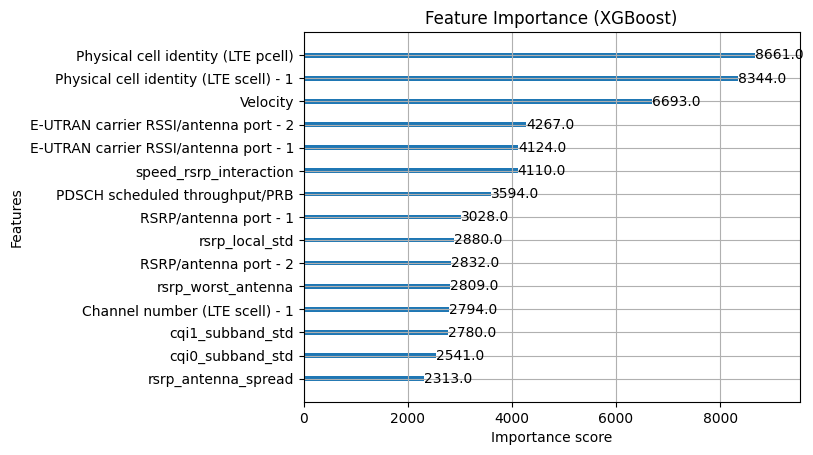

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(xgb_model, max_num_features=15)
plt.title("Feature Importance (XGBoost)")
plt.show()